In [2]:
from ucimlrepo import fetch_ucirepo
secom = fetch_ucirepo(id=179)
df = secom.data.original
df.head()

,class,timestamp,Attribute 1,Attribute 2,Attribute 3,Attribute 4,Attribute 5,Attribute 6,Attribute 7,Attribute 8,...,Attribute 581,Attribute 582,Attribute 583,Attribute 584,Attribute 585,Attribute 586,Attribute 587,Attribute 588,Attribute 589,Attribute 590
0,-1,19/07/2008 11:55:00,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,...,NaN,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN
1,-1,19/07/2008 12:32:00,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,...,0.0060,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045
2,1,19/07/2008 13:17:00,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,...,0.0148,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602
3,-1,19/07/2008 14:43:00,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,...,0.0044,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432
4,-1,19/07/2008 15:22:00,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,...,NaN,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432


In [3]:
print(df.shape)
df.isnull().sum().sum()
df['class'].value_counts()

(1567, 592)


class
-1    1463
 1     104
Name: count, dtype: int64

In [4]:
missing = df.isnull().sum() / len(df) * 100
missing[missing > 0].sort_values(ascending=False).head(20)

Attribute 293    91.193363
Attribute 294    91.193363
Attribute 158    91.193363
Attribute 159    91.193363
Attribute 359    85.577537
Attribute 86     85.577537
Attribute 493    85.577537
Attribute 221    85.577537
Attribute 519    64.964901
Attribute 247    64.964901
Attribute 246    64.964901
Attribute 517    64.964901
Attribute 518    64.964901
Attribute 111    64.964901
Attribute 385    64.964901
Attribute 383    64.964901
Attribute 384    64.964901
Attribute 110    64.964901
Attribute 245    64.964901
Attribute 112    64.964901
dtype: float64

In [5]:
df_clean = df.dropna(thresh=len(df)*0.5, axis=1)
print(df_clean.shape)

(1567, 564)


In [6]:
df_clean = df_clean.fillna(df_clean.mean(numeric_only=True))

In [7]:
df_clean.isnull().sum().sum()

np.int64(0)

In [8]:
X = df_clean.drop(columns=['class', 'timestamp'])
y = df_clean['class']

print(X.shape)
print(y.value_counts())

(1567, 562)
class
-1    1463
 1     104
Name: count, dtype: int64


In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          -1       0.92      1.00      0.96       290
           1       0.00      0.00      0.00        24

    accuracy                           0.92       314
   macro avg       0.46      0.50      0.48       314
weighted avg       0.85      0.92      0.89       314



C:\Users\jinhy\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\jinhy\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\jinhy\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [11]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_resampled, y_resampled = sm.fit_resample(X_train, y_train)

model2 = RandomForestClassifier(n_estimators=100, random_state=42)
model2.fit(X_resampled, y_resampled)

y_pred2 = model2.predict(X_test)
print(classification_report(y_test, y_pred2))

              precision    recall  f1-score   support

          -1       0.92      1.00      0.96       290
           1       0.00      0.00      0.00        24

    accuracy                           0.92       314
   macro avg       0.46      0.50      0.48       314
weighted avg       0.85      0.92      0.89       314



C:\Users\jinhy\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\jinhy\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\jinhy\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [12]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE

secom = fetch_ucirepo(id=179)
df = secom.data.original

df_clean = df.dropna(thresh=len(df)*0.5, axis=1)
df_clean = df_clean.fillna(df_clean.mean(numeric_only=True))

X = df_clean.drop(columns=['class', 'timestamp'])
y = df_clean['class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

sm = SMOTE(random_state=42)
X_resampled, y_resampled = sm.fit_resample(X_train, y_train)


model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_resampled, y_resampled)

print(classification_report(y_test, model.predict(X_test)))

              precision    recall  f1-score   support

          -1       0.92      1.00      0.96       290
           1       0.00      0.00      0.00        24

    accuracy                           0.92       314
   macro avg       0.46      0.50      0.48       314
weighted avg       0.85      0.92      0.89       314



C:\Users\jinhy\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\jinhy\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\jinhy\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [13]:
print(y_resampled.value_counts())

class
-1    1173
 1    1173
Name: count, dtype: int64


In [14]:
y_prob = model.predict_proba(X_test)[:, 1]

y_pred_adj = (y_prob >= 0.3).astype(int)
y_pred_adj = pd.Series(y_pred_adj).map({0: -1, 1: 1})

print(classification_report(y_test, y_pred_adj))

              precision    recall  f1-score   support

          -1       0.94      0.88      0.91       290
           1       0.17      0.29      0.22        24

    accuracy                           0.84       314
   macro avg       0.55      0.59      0.56       314
weighted avg       0.88      0.84      0.86       314



In [15]:
y_pred_adj = (y_prob >= 0.2).astype(int)
y_pred_adj = pd.Series(y_pred_adj).map({0: -1, 1: 1})
print(classification_report(y_test, y_pred_adj))

              precision    recall  f1-score   support

          -1       0.95      0.72      0.82       290
           1       0.15      0.58      0.23        24

    accuracy                           0.71       314
   macro avg       0.55      0.65      0.53       314
weighted avg       0.89      0.71      0.77       314



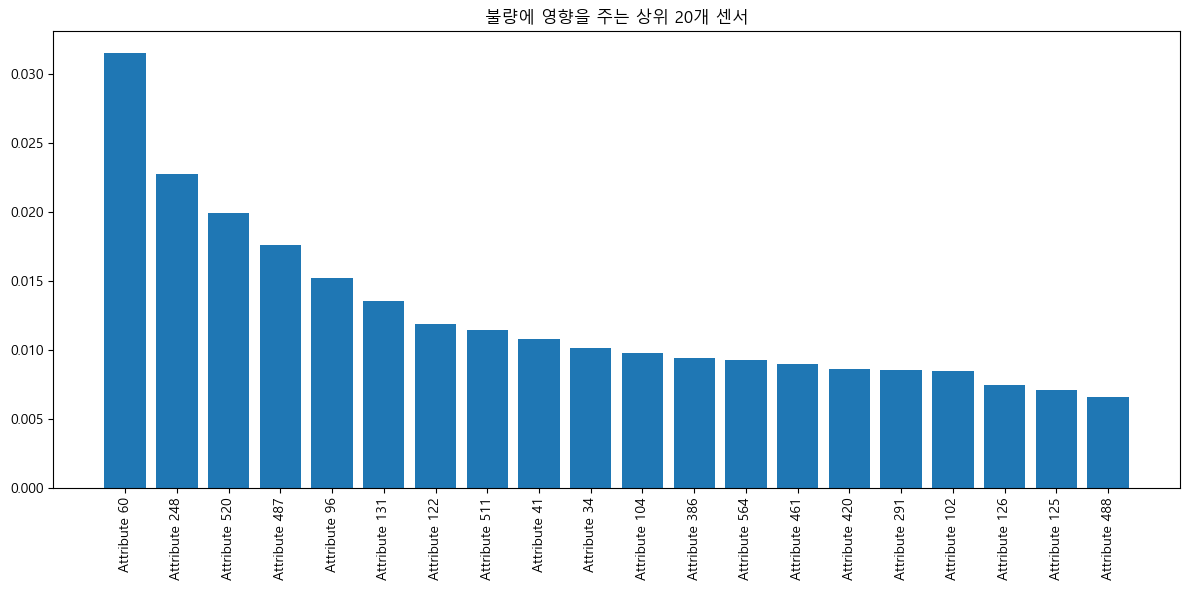

In [16]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'

importances = model.feature_importances_
feature_names = X.columns
indices = importances.argsort()[::-1][:20]


plt.figure(figsize=(12, 6))
plt.bar(range(20), importances[indices])
plt.xticks(range(20), [feature_names[i] for i in indices], rotation=90)
plt.title('불량에 영향을 주는 상위 20개 센서')
plt.tight_layout()
plt.show()

In [17]:
result = X_test.copy()
result['실제'] = y_test.values
result['예측'] = y_pred_adj.values
result.to_csv('secom_result.csv', index=False)
print("저장 완료")

저장 완료


In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, recall_score, precision_score, f1_score

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_res, y_train_res)

lr_proba = lr_model.predict_proba(X_test)[:, 1]
lr_pred = (lr_proba >= 0.2).astype(int)

rf_proba = model.predict_proba(X_test)[:, 1]
rf_pred = (rf_proba >= 0.2).astype(int)

import pandas as pd
comparison = pd.DataFrame({
    '모델': ['RandomForest', 'LogisticRegression'],
    'Precision': [precision_score(y_test, rf_pred), precision_score(y_test, lr_pred)],
    'Recall': [recall_score(y_test, rf_pred), recall_score(y_test, lr_pred)],
    'F1': [f1_score(y_test, rf_pred), f1_score(y_test, lr_pred)]
})
print(comparison.to_string(index=False))

NameError: name 'X_train_res' is not defined

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_resampled, y_resampled)

lr_proba = lr_model.predict_proba(X_test)[:, 1]
lr_pred = (lr_proba >= 0.2).astype(int)
lr_pred = pd.Series(lr_pred).map({0: -1, 1: 1})

rf_proba = model.predict_proba(X_test)[:, 1]
rf_pred = (rf_proba >= 0.2).astype(int)
rf_pred = pd.Series(rf_pred).map({0: -1, 1: 1})

comparison = pd.DataFrame({
    '모델': ['RandomForest', 'LogisticRegression'],
    'Precision': [precision_score(y_test, rf_pred, pos_label=1), precision_score(y_test, lr_pred, pos_label=1)],
    'Recall': [recall_score(y_test, rf_pred, pos_label=1), recall_score(y_test, lr_pred, pos_label=1)],
    'F1': [f1_score(y_test, rf_pred, pos_label=1), f1_score(y_test, lr_pred, pos_label=1)]
})
print(comparison.to_string(index=False))

                모델  Precision   Recall       F1
      RandomForest   0.145833 0.583333 0.233333
LogisticRegression   0.111111 0.541667 0.184397


C:\Users\jinhy\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score

# 스케일링 추가
scaler = StandardScaler()
X_resampled_scaled = scaler.fit_transform(X_resampled)
X_test_scaled = scaler.transform(X_test)

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_resampled_scaled, y_resampled)

lr_proba = lr_model.predict_proba(X_test_scaled)[:, 1]
lr_pred = (lr_proba >= 0.2).astype(int)
lr_pred = pd.Series(lr_pred).map({0: -1, 1: 1})

rf_proba = model.predict_proba(X_test)[:, 1]
rf_pred = (rf_proba >= 0.2).astype(int)
rf_pred = pd.Series(rf_pred).map({0: -1, 1: 1})

comparison = pd.DataFrame({
    '모델': ['RandomForest', 'LogisticRegression'],
    'Precision': [precision_score(y_test, rf_pred, pos_label=1), precision_score(y_test, lr_pred, pos_label=1)],
    'Recall': [recall_score(y_test, rf_pred, pos_label=1), recall_score(y_test, lr_pred, pos_label=1)],
    'F1': [f1_score(y_test, rf_pred, pos_label=1), f1_score(y_test, lr_pred, pos_label=1)]
})
print(comparison.to_string(index=False))

                모델  Precision   Recall       F1
      RandomForest   0.145833 0.583333 0.233333
LogisticRegression   0.170213 0.333333 0.225352


In [24]:
thresholds_missing = [0.3, 0.5, 0.7]
results_missing = []
for thresh in thresholds_missing:
    df_temp = df.dropna(thresh=len(df)*thresh, axis=1)
    df_temp = df_temp.fillna(df_temp.mean(numeric_only=True))

    X_temp = df_temp.drop(columns=['class', 'timestamp'])
    y_temp = df_temp['class']

    X_tr, X_te, y_tr, y_te = train_test_split(X_temp, y_temp, test_size=0.2, random_state=42)

    sm = SMOTE(random_state=42)
    X_tr_res, y_tr_res = sm.fit_resample(X_tr, y_tr)

    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X_tr_res, y_tr_res)

    proba = rf.predict_proba(X_te)[:, 1]
    pred = (proba >= 0.2).astype(int)
    pred = pd.Series(pred).map({0: -1, 1: 1})

    results_missing.append({
        '결측치 기준': f'{int(thresh*100)}%',
        '남은 컬럼 수': X_temp.shape[1],
        'Recall': recall_score(y_te, pred, pos_label=1),
        'Precision': precision_score(y_te, pred, pos_label=1),
        'F1': f1_score(y_te, pred, pos_label=1)
    })
df_missing = pd.DataFrame(results_missing)
print(df_missing.to_string(index=False))

결측치 기준  남은 컬럼 수   Recall  Precision       F1
   30%      582 0.708333   0.160377 0.261538
   50%      562 0.583333   0.145833 0.233333
   70%      558 0.625000   0.132743 0.218978


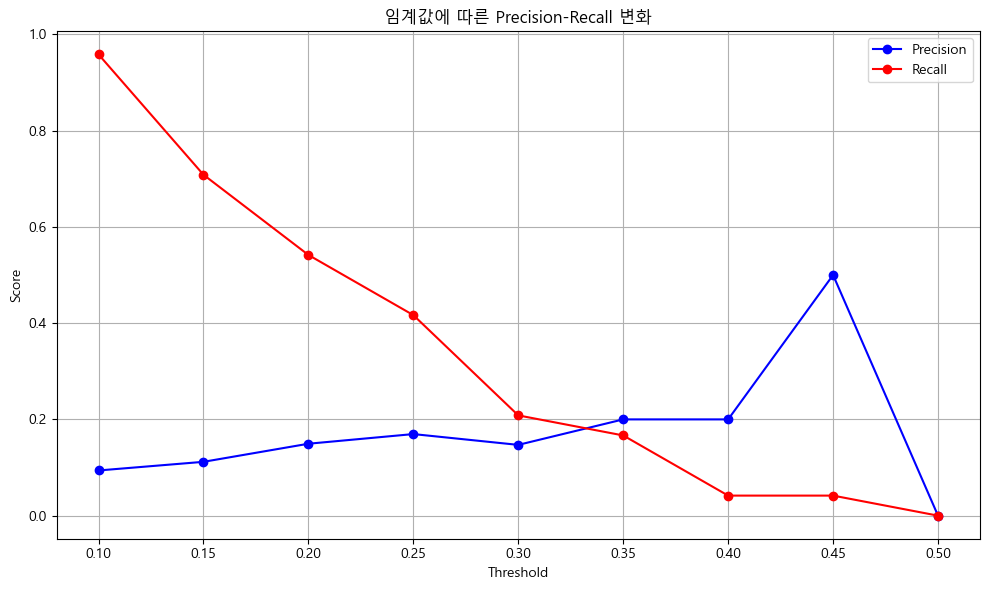

최적 임계값: 0.25
Precision: 0.169, Recall: 0.417, F1: 0.241


In [26]:
import numpy as np

thresholds = np.arange(0.1, 0.55, 0.05)
precisions = []
recalls = []

rf_proba = model.predict_proba(X_test)[:, 1]

for t in thresholds:
    pred = (rf_proba >= t).astype(int)
    pred = pd.Series(pred).map({0: -1, 1: 1})
    precisions.append(precision_score(y_test, pred, pos_label=1, zero_division=0))
    recalls.append(recall_score(y_test, pred, pos_label=1))

plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions, 'b-o', label='Precision')
plt.plot(thresholds, recalls, 'r-o', label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('임계값에 따른 Precision-Recall 변화')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

f1s = [2*p*r/(p+r) if (p+r) > 0 else 0 for p, r in zip(precisions, recalls)]
best_idx = np.argmax(f1s)
print(f"최적 임계값: {thresholds[best_idx]:.2f}")
print(f"Precision: {precisions[best_idx]:.3f}, Recall: {recalls[best_idx]:.3f}, F1: {f1s[best_idx]:.3f}")